# Notebook 6 — Mixtures

*SWC ENC 2026 · behaviour module*

Real mice don't use a single pure strategy. Notebooks 3–5 built the
**fit → evaluate → ablate** cycle and checked it on clean single-strategy mice.
Now we stress-test it on mice that genuinely *blend* the visual and timing
strategies, and ask the sharper question: does the **strategy index** track the
true blend?

Everything here reuses the backend you've already built — `fit_static`,
`cross_val_auc`, `ablation_loglik_deltas`. The only new thing is that we dial the
mouse's strategy continuously.

**In this notebook you will:**
1. Generate mice along a **continuum** from pure-visual to pure-timing.
2. Confirm the recovered **strategy index** tracks the true blend.
3. Populate the strategy-space cloud of Figure 2F.

---
**The paper panel this notebook reproduces**

<img alt="Piet et al., Figure 2F - sessions plotted in strategy space by their visual and timing indices" src="../assets/paper/fig2f.png" width="420">

*Fig. 2F — every session placed in strategy space by its visual index and timing
index. This notebook populates that cloud using mice that blend the two strategies.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swcbehav as sb

def get_Xy(sess):
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    return X, y, cols

## 1. A continuum of mice

A static mouse is just a weight vector, so we can build any blend we like with
the public generator: `make_session` for the stimulus, `constant_weights` for the
strategy, `simulate` to produce behavior. We parameterize the blend by
$\alpha \in [0, 1]$: $\alpha = 1$ is pure visual, $\alpha = 0$ is pure timing,
holding the total strategy strength fixed.

**Exercise 1** *(~5 min)*. Complete `make_blend_mouse`.

> **Check / unstuck.** Hit rate should rise from ~0.22 (α=0, pure timing) to ~0.88
> (α=1, pure visual). Stuck? The solutions copy has it.

In [2]:
def make_blend_mouse(alpha, seed=0, total=5.0, bias=-3.0, n_images=4800):
    stim = sb.make_session(n_images=n_images, seed=seed)
    weights = sb.constant_weights(bias=bias, visual=total * alpha,
                                  timing=total * (1 - alpha))
    return sb.simulate(stim, weights, seed=seed + 1)

In [3]:
# Behavioral signatures shift smoothly as we slide from timing to visual.
print(f"{'alpha':>6s}{'hit rate':>10s}{'false alarm':>13s}")
for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    t = make_blend_mouse(alpha, seed=0).table
    ch = t["is_change"].to_numpy(); b = t["bout_start"].to_numpy()
    print(f"{alpha:6.2f}{b[ch].mean():10.2f}{b[~ch].mean():13.2f}")

 alpha  hit rate  false alarm
  0.00      0.22         0.20
  0.25      0.38         0.16
  0.50      0.57         0.12
  0.75      0.78         0.08
  1.00      0.88         0.05


## 2. Does the strategy index track the blend?

Run the ablation cycle on each mouse and compute the strategy index
$\Delta_{\text{visual}} - \Delta_{\text{timing}}$. If the method works, the index
should rise monotonically with $\alpha$ — recovering the blend we dialed in.

**Exercise 2** *(~3 min · easy)*. Complete `strategy_index` using `sb.ablation_loglik_deltas`.

> **Check / unstuck.** The recovered index should climb steadily with α in the next
> plot. Stuck? The solutions copy has it.

In [4]:
def strategy_index(sess):
    X, y, cols = get_Xy(sess)
    d = sb.ablation_loglik_deltas(X, y, cols)
    return d["visual"], d["timing"], d["visual"] - d["timing"]

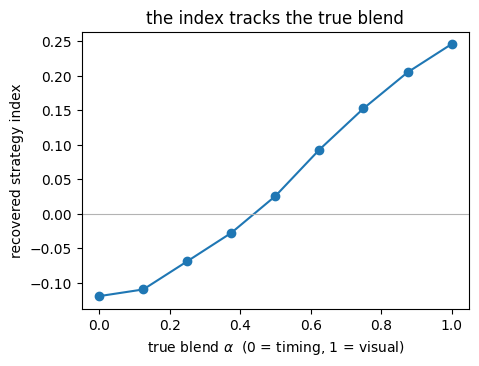

In [5]:
alphas = np.linspace(0, 1, 9)
indices = np.array([strategy_index(make_blend_mouse(a, seed=0))[2] for a in alphas])

plt.figure(figsize=(5, 3.6))
plt.plot(alphas, indices, "o-")
plt.axhline(0, color="0.7", lw=0.8)
plt.xlabel(r"true blend $\alpha$  (0 = timing, 1 = visual)")
plt.ylabel("recovered strategy index")
plt.title("the index tracks the true blend")
plt.show()

The recovered index climbs steadily from negative (timing-dominant) through zero
(balanced) to positive (visual-dominant) as we slide $\alpha$ from 0 to 1. The
method reads the blend out of behavior — this is the recovery guarantee that lets
us trust the same index on *real* mice, where there is no $\alpha$ to check
against.

## 3. The strategy-space cloud (Figure 2F)

Finally, populate the visual-vs-timing plane with a spread of blends and seeds,
colored by the strategy index — the synthetic counterpart of the paper's
Figure 2F.

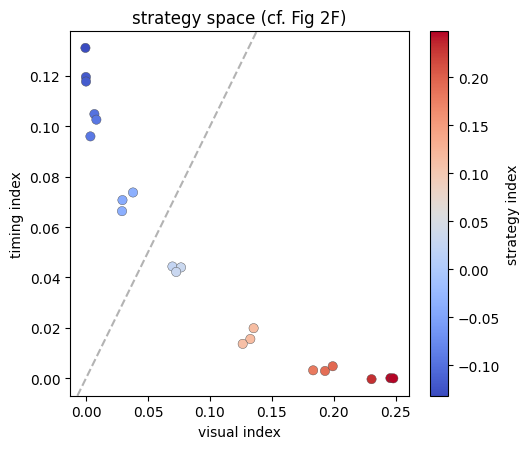

In [6]:
plt.figure(figsize=(5.4, 4.6))
vis, tim, strat = [], [], []
for alpha in np.linspace(0, 1, 7):
    for seed in range(3):
        vi, ti, si = strategy_index(make_blend_mouse(alpha, seed=seed))
        vis.append(vi); tim.append(ti); strat.append(si)
sc = plt.scatter(vis, tim, c=strat, cmap="coolwarm", s=45, edgecolor="0.3", lw=0.3)
plt.colorbar(sc, label="strategy index")
plt.xlabel("visual index"); plt.ylabel("timing index")
plt.axline((0, 0), slope=1, color="0.7", ls="--")
plt.title("strategy space (cf. Fig 2F)")
plt.tight_layout(); plt.show()

Mice fan out along an anti-diagonal band: as one strategy strengthens the other
weakens, and the strategy index (color) sweeps from blue to red across the cloud
— exactly the structure Piet et al. report across their real sessions.

One honest caveat worth raising with students: visual and timing are not perfectly
separable. A lick on a change that also happens to follow a long wait is evidence
for *either* strategy, so at intermediate blends the two indices trade off with
some noise. Held-out prediction keeps this in check, but it's a real limit of
inferring latent strategy from behavior alone.

---
## 4. (Optional add-on) Correlation and a linear fit — Figure 2E

*Self-contained — you can skip it, or leave it for self-study, without affecting
anything later.*

Figures 2E and 2G ask a different kind of question from the rest of this notebook:
not "what is *this* mouse's strategy?" but "across the population, do two measured
quantities **move together**?" The tool for that is a **correlation** summarized by
a straight-line (**linear**) fit. As a concrete case, let's ask whether a mouse's
*recovered visual weight* predicts its *hit rate*, across mice with differing
visual strength. First, build the population and measure the two quantities
*(~5 s to fit)*:

In [7]:
rng = np.random.default_rng(0)
visual_weight, hit_rate = [], []
for i in range(40):
    v = rng.uniform(0.0, 5.0)                                   # this mouse's visual strength
    b = rng.uniform(-4.0, -2.0)                                 # and its baseline lick drive
    stim = sb.make_session(n_images=1200, seed=100 + i)
    sess = sb.simulate(stim, sb.constant_weights(bias=b, visual=v, timing=1.0),
                       seed=200 + i)
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    visual_weight.append(sb.fit_static(X, y)[1])               # recovered visual weight
    t = sess.table
    hit_rate.append(t["bout_start"][t["is_change"]].mean())    # measured hit rate
visual_weight, hit_rate = np.array(visual_weight), np.array(hit_rate)

Two numbers capture the relationship. **Pearson's $r$** measures how tightly the
points hug a straight line (from $-1$ through $0$ to $+1$); its square **$R^2$** is
the fraction of the variance in one quantity that the line through the other
accounts for. The line itself, $y \approx a x + b$, comes from least squares (the
`np.polyfit(x, y, 1)` you may know).

**Exercise 3** *(~6 min)*. Complete `correlate`: return the least-squares slope and intercept,
Pearson's $r$, and $R^2$. *Hints:* `np.polyfit(x, y, 1)` gives `(slope, intercept)`;
`np.corrcoef(x, y)[0, 1]` gives $r$.

> **Check / unstuck.** Expect **r ≈ 0.93, R² ≈ 0.87**. Stuck? Use `sb.linear_fit(x, y)`
> (returns a dict with `slope`, `intercept`, `r`, `r2`).

In [8]:
def correlate(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    slope, intercept = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
    return slope, intercept, r, r ** 2

slope, intercept, r, r2 = correlate(visual_weight, hit_rate)
print(f"r = {r:.2f},  R^2 = {r2:.2f}")

r = 0.93,  R^2 = 0.87


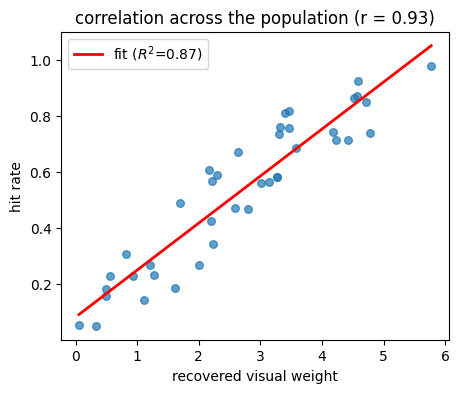

In [9]:
plt.figure(figsize=(5, 4))
plt.scatter(visual_weight, hit_rate, s=30, alpha=0.7)
xs = np.array([visual_weight.min(), visual_weight.max()])
plt.plot(xs, slope * xs + intercept, "r-", lw=2, label=f"fit ($R^2$={r2:.2f})")
plt.xlabel("recovered visual weight"); plt.ylabel("hit rate")
plt.title(f"correlation across the population (r = {r:.2f})"); plt.legend()
plt.show()

A correlation invites a significance question: could a slope this steep arise by
chance from unrelated quantities? A quick, assumption-light way to check is a
**permutation test** — scramble the pairing between the two quantities many times,
each time recomputing $r$, and see how often chance alone beats what we observed.
(Notebook 9 develops permutation tests properly; this is a preview.)

In [10]:
perm = np.array([abs(np.corrcoef(visual_weight, rng.permutation(hit_rate))[0, 1])
                 for _ in range(2000)])
p = (np.sum(perm >= abs(r)) + 1) / (len(perm) + 1)
print(f"observed |r| = {abs(r):.2f};  permutation p = {p:.4f}")

observed |r| = 0.93;  permutation p = 0.0005


## Wrap-up

The static cycle survives contact with mixed strategies: the strategy index
recovers the blend and lays out the Figure 2F cloud. But every mouse so far has
held its strategy *fixed* for the whole session.

**Next (Notebook 7 — the climax):** the dynamic mouse, whose strategy drifts. We
watch the static model fail, discover the fix by fitting it in sliding windows,
and then tie those windows together into the dynamic model.